In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Import CNN layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# Load training and testing CSV files

train_data = pd.read_csv("fashion-mnist_train.csv")
test_data = pd.read_csv("fashion-mnist_test.csv")

In [3]:
# First column = labels
# Remaining columns = pixel values

x_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

x_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

In [4]:
# Convert pixel values from 0-255 to 0-1

x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# Reshape into 28x28 image format

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
# Fashion category names

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

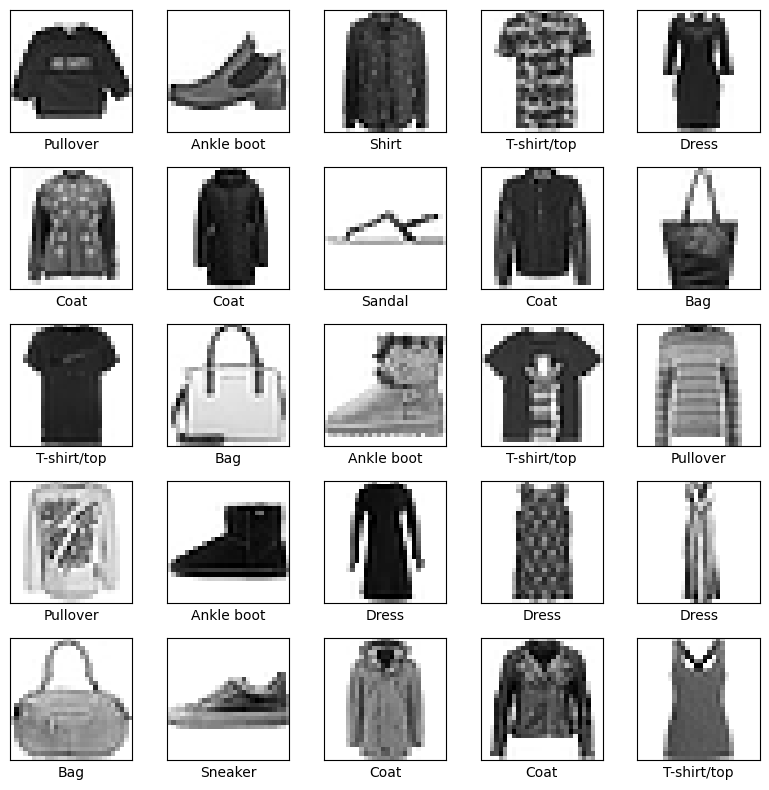

In [7]:
# Show first 25 training images

plt.figure(figsize=(8,8))

for i in range(25):

    # Create 5x5 grid
    plt.subplot(5,5,i+1)

    # Remove axis numbers
    plt.xticks([])
    plt.yticks([])

    # Remove grid
    plt.grid(False)

    # Display image
    plt.imshow(x_train[i], cmap='binary')

    # Show actual label
    plt.xlabel(class_names[y_train[i]])

# Adjust spacing
plt.tight_layout()

# Show images
plt.show()

In [ ]:
# Create CNN model

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu', input_shape=(28,28,1)))

# First Pooling Layer
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D((2,2)))

# Convert 2D data into 1D
model.add(Flatten())

# Hidden Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

c:\Users\Sumit\desktop\anaconda\envs\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train the CNN model

model.fit(
    x_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.8396 - loss: 0.4463
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8921 - loss: 0.2976
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9058 - loss: 0.2528
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9179 - loss: 0.2221
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9275 - loss: 0.1942


In [11]:
# Test model accuracy

loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9115 - loss: 0.2416
Test Accuracy: 0.9114999771118164


In [12]:
# Predict output probabilities

prediction = model.predict(x_test)

# Convert probabilities into class labels
y_pred = np.argmax(prediction, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


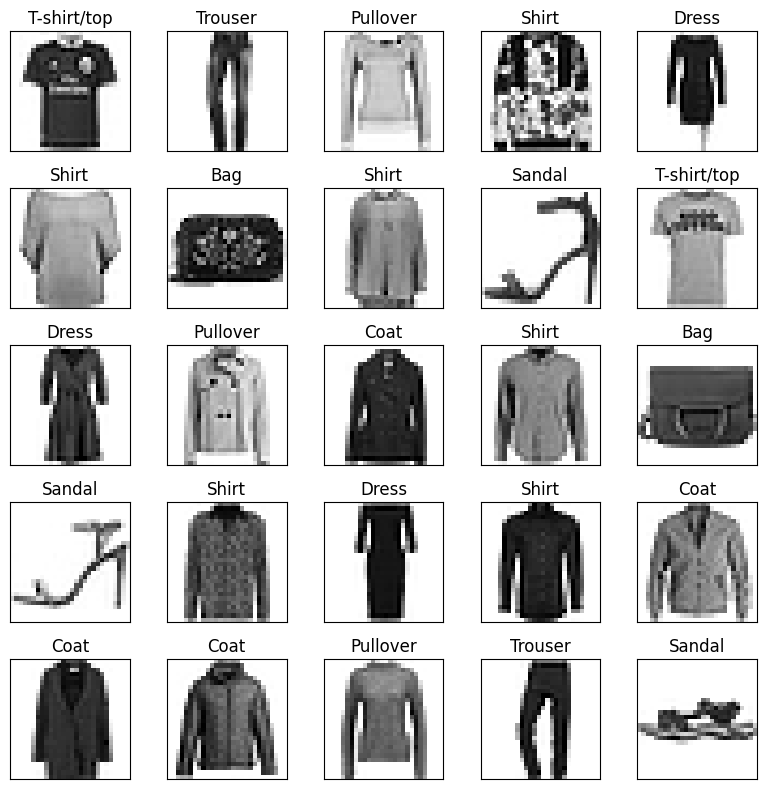

In [13]:
# Show first 25 test images with predicted labels

plt.figure(figsize=(8,8))

for i in range(25):

    # Create 5x5 grid
    plt.subplot(5,5,i+1)

    # Remove axis numbers
    plt.xticks([])
    plt.yticks([])

    # Remove grid
    plt.grid(False)

    # Display image
    plt.imshow(x_test[i], cmap='binary')

    # Show predicted label
    plt.title(class_names[y_pred[i]])

# Adjust spacing
plt.tight_layout()

# Show images
plt.show()